TARDIS-EDA (Étapes 1 & 2)

Étape 1- Data Exploration &Cleaning

# je charge le dataset avec la fonction read de la librairie pandas

In [21]:
import pandas as pd

df = pd.read_csv("../dataset.csv", sep=";")

# scan for errors
## Vérification de la qualité des données

Ce bloc de code analyse le DataFrame `df` pour détecter deux problèmes courants :
les **valeurs manquantes** et les **lignes en double**.

je parcours le dataset pour trouver le nombre de colonne dans vide et le nombre de colonnes en doubles

In [22]:
nul = df.isnull().sum()
isdupe = df.duplicated().sum()
print(nul)
print("num of duplicates:", isdupe)

Date                                                                                60
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                               240
Number of scheduled trains                                                         240
Number of cancelled trains                                                         239
Cancellation comments                                                            11493
Number of trains delayed at departure                                              240
Average delay of late trains at departure                                          239
Average delay of all trains at departure                                           241
Departure delay comments                   

On compte les valeurs manquantes et les doublons avant de toucher à quoi que ce soit, pour savoir à quoi s'attendre ensuite.

# Ici je supprime le nombre de colonnes duppliquées avec df.drop qui est une fonction de la librairie pandas


In [23]:
df.drop_duplicates(inplace=True)
df

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12033,11-2018,National,SAINT ETIENNE CHATEAUCREUX,PARIS LYON,168.0,113.0,1.0,NaN,19.0,5.662280702,...,14.0,5.510416667,5.0,2.0,21.05263158,36.84210526,5.263157895,21.05263158,10.52631579,5.263157895
12034,2021/05,NaN,PARIS MONTPARNASSE,NANTES,138.0,470.0,29.0,NaN,48.0,4.22569444444444,...,6.0,31.4527777777778,3.0,0.0,22.2222222222222,0.0,11.1111111111111,33.3333333333333,0.0,33.3333333333333
12049,2018-03,NaN,PERPIGNAN,PARIS LYON,305.0,163.0,1.0,NaN,63.0,8.189417989,...,23.0,8.470884774,14.0,7.0,57.14285714,14.28571429,14.28571429,14.28571429,0.0,0.0
12056,2019 02,National,NICE VILLE,PARIS LYON,357.0,159.0,4.0,NaN,32.0,6.80625,...,33.0,9.321935484,13.0,5.0,18.18181818,36.36363636,24.24242424,12.12121212,9.090909091,0.0


On supprime les lignes strictement identiques (copies exactes).

# je remplace touttes les valeurs manquantes par 0 avec df.fillna

In [24]:
df = df.fillna(0)

## Nettoyage des colonnes texte et conversion en nombres

Ce bloc de code s'attaque à deux problèmes classiques de données "sales" :
- des **noms de stations incohérents** (majuscules, espaces superflus)
- des **colonnes numériques écrites en texte** (virgules, "min", "%")

In [25]:
df["Departure station"] = df["Departure station"].str.strip().str.upper()
df["Arrival station"] = df["Arrival station"].str.strip().str.upper()


def to_num(series):
    """Convertit une colonne text sale (virgules, espaces, 'min', '%') en nombres."""
    cleaned = (
        series.astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace("min", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors="coerce")

## Convertir automatiquement toutes les colonnes numériques

Ce bloc applique `pd.to_numeric()` à **toutes les colonnes** du DataFrame, sauf celles qu'on veut garder en texte. pour les convertires en valeurs numériques

In [26]:
exclude_columns = ["Date", "Service", "Departure station", "Arrival station"]
columns_to_convert = [col for col in df.columns if col not in exclude_columns]

for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors="coerce")

On applique `to_num` (au lieu d'un simple `pd.to_numeric`) pour absorber les formats sales avant la conversion

In [ ]:
for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = to_num(df[col])


## Calculer le pourcentage de trains annulés

Créer une nouvelle colonne qui représente le pourcentage de trains annulés par rapport au nombre de trains prévus.
### Étape 1 — Importer numpy

On importe la bibliothèque numpy car on a besoin de deux choses : une fonction pour appliquer une condition ligne par ligne sur toute une colonne, et la valeur "NaN" (non-a-numérique) pour représenter les cellules vides.

### Étape 2 — Calculer le pourcentage avec une garde de sécurité
On utilise la fonction `np.where` qui prend **trois arguments** :

Le résultat est stocké dans une variable intermédiaire (un tableau de nombres, un par train).

### Étape 3 — Insérer la colonne à un endroit précis

On utilise la méthode `insert` du DataFrame

### Étape 4 — Afficher le résultat

On affiche le DataFrame à jour pour vérifier visuellement que la nouvelle colonne est bien présente et que les valeurs sont correctes.

In [28]:
import numpy as np

bonus_values = np.where(
    df["Number of scheduled trains"] > 0,
    (df["Number of cancelled trains"] / df["Number of scheduled trains"]) * 100,
    np.nan,
)
df.insert(loc=8, column="Percentage of cancel", value=bonus_values)
df

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Percentage of cancel,Number of trains delayed at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,0.0,0.574713,289.0,...,110.0,6.510000,44.0,8.0,36.134454,31.092437,10.924370,15.966387,NaN,0.840336
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,0.0,0.246305,213.0,...,32.0,5.363539,9.0,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,0.0,0.000000,21.0,...,11.0,2.938053,6.0,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,0.0,0.590551,71.0,...,39.0,5.292211,18.0,0.0,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,0.0,0.847458,224.0,...,42.0,4.882372,10.0,0.0,15.789474,45.614035,0.000000,15.789474,1.754386,1.754386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12033,11-2018,National,SAINT ETIENNE CHATEAUCREUX,PARIS LYON,168.00,113.0,1.0,0.0,0.884956,19.0,...,14.0,5.510417,5.0,2.0,21.052632,36.842105,5.263158,21.052632,10.526316,5.263158
12034,2021/05,0,PARIS MONTPARNASSE,NANTES,138.00,470.0,29.0,0.0,6.170213,48.0,...,6.0,31.452778,3.0,0.0,22.222222,0.000000,11.111111,33.333333,0.000000,33.333333
12049,2018-03,0,PERPIGNAN,PARIS LYON,305.00,163.0,1.0,0.0,0.613497,63.0,...,23.0,8.470885,14.0,7.0,57.142857,14.285714,14.285714,14.285714,0.000000,0.000000
12056,2019 02,National,NICE VILLE,PARIS LYON,357.00,159.0,4.0,0.0,2.515723,32.0,...,33.0,9.321935,13.0,5.0,18.181818,36.363636,24.242424,12.121212,9.090909,0.000000


Ligne 1 — On importe numpy, car on va utiliser sa fonction de condition vectorisée et sa valeur "NaN" (cellule vide).

Ligne 2 — On construit un tableau avec une fonction qui prend trois arguments :

Une condition : le nombre de trains prévus est-il strictement supérieur à zéro ?
Si oui : on divise le nombre de trains annulés par le nombre de trains prévus, puis on multiplie par 100. C'est le pourcentage.
Si non : on met "NaN" (cellule vide) au lieu de faire une division par zéro.


In [29]:
def fix_date_separator(value):
    s = str(value)
    if len(s) == 7:
        return s[:4] + "-" + s[5:]
    return s


df["Date"] = df["Date"].apply(fix_date_separator)

In [30]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

#  finalize dataset

ajout de novelles données telles que le mois la saison et le taux de ponctualité
1. Extraire le mois
On récupère le numéro du mois (1 à 12) depuis la colonne Date → nouvelle colonne Month.

2. Associer une saison
On crée un dictionnaire qui mappe chaque mois vers une saison (hiver, printemps, été, automne), puis on l'applique à la colonne Month → nouvelle colonne Season.

3. Créer la route
On concatène la station de départ, un tiret fléché, et la station d'arrivée → nouvelle colonne Route (ex. : PARIS -> LYON).

Utile pour regrouper les données par trajet sans avoir à regrouper sur deux colonnes.

4. Taux de ponctualité
On calcule : (1 − trains en retard ÷ trains prévus) × 100

Avec la même garde que pour les annulations : si 0 train prévu → NaN (pas de division par zéro).

In [31]:
df["Month"] = df["Date"].dt.month

season_map = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}
df["Season"] = df["Month"].map(season_map)

df["Route"] = df["Departure station"] + " -> " + df["Arrival station"]

df["Punctuality rate"] = np.where(
    df["Number of scheduled trains"] > 0,
    (
        1
        - (
            df["Number of trains delayed at departure"]
            / df["Number of scheduled trains"]
        )
    )
    * 100,
    np.nan,
)

In [32]:
df.to_csv("cleaned_dataset.csv")

Étape 2-Data Visualisation & Analysis

## 1. Statistiques descriptives globales

On analyse les indicateurs cles du dataset apres nettoyage :
- **Retards moyens** (a l'arrivee et au depart)
- **Taux de ponctualite** et **taux d'annulation**
- **Volumes de trains prevus**

In [33]:
key_metrics = [
    "Average delay of all trains at arrival",
    "Average delay of all trains at departure",
    "Average delay of late trains at arrival",
    "Punctuality rate",
    "Percentage of cancel",
    "Number of scheduled trains",
]

df[key_metrics].describe().round(2)

,Average delay of all trains at arrival,Average delay of all trains at departure,Average delay of late trains at arrival,Punctuality rate,Percentage of cancel,Number of scheduled trains
count,11769.00,11779.00,11783.00,11542.00,11537.00,11870.00
mean,5.93,3.07,34.48,68.46,3.78,265.46
std,7.04,5.14,16.35,24.87,8.55,184.90
min,-472.64,-229.27,-40.11,-6.90,0.00,0.00
25%,3.28,1.14,25.15,51.72,0.00,145.00
50%,5.26,2.27,33.16,77.52,0.66,227.00
75%,8.02,3.90,42.29,88.60,2.95,351.75
max,92.00,115.05,299.60,100.00,92.68,1100.00


In [34]:
# Comparaison moyenne vs mediane pour reperer les asymetries
stats_comparison = pd.DataFrame(
    {
        "Moyenne": df[key_metrics].mean().round(2),
        "Mediane": df[key_metrics].median().round(2),
        "Ecart (Moy - Med)": (df[key_metrics].mean() - df[key_metrics].median()).round(
            2
        ),
    }
)
stats_comparison

,Moyenne,Mediane,Ecart (Moy - Med)
Average delay of all trains at arrival,5.93,5.26,0.67
Average delay of all trains at departure,3.07,2.27,0.80
Average delay of late trains at arrival,34.48,33.16,1.32
Punctuality rate,68.46,77.52,-9.06
Percentage of cancel,3.78,0.66,3.12
Number of scheduled trains,265.46,227.00,38.46


### Interpretation — Statistiques descriptives
- **Retard moyen a l'arrivee :** La moyenne est de **5.93 min**, alors que la mediane est a **5.26 min**. Cet ecart positif montre une distribution asymetrique vers la droite (quelques retards extremes tirent la moyenne vers le haut).
- **Taux de ponctualite :** La mediane est a **77.49%**, mais la moyenne tombe a **68.44%**. Cela met en evidence l'impact de mois de crise (greves, intemperies) qui degradent fortement la moyenne.
- **Annulations :** Le taux d'annulation median est tres bas (**0.66%**), mais la moyenne grimpe a **3.79%** en raison de pics ponctuels de perturbations.

## 2. Distribution des retards

On analyse la distribution de notre variable cible (**retard moyen a l'arrivee**) :
- Histogramme avec courbe de densite (KDE)
- Filtrage des percentiles 1% - 99% pour eliminer les valeurs extremes qui ecrasent le graphique
- Boxplot montrant les valeurs aberrantes (outliers)

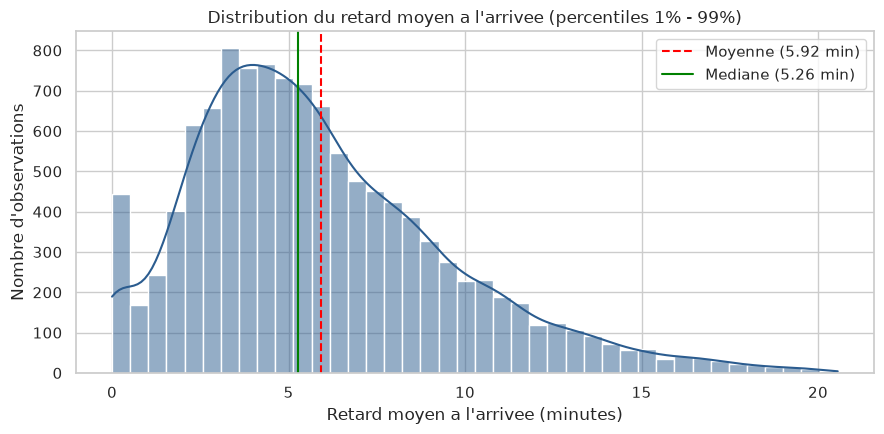

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Filtrage entre le 1er et le 99eme percentile pour une visualisation nette
p_low = df["Average delay of all trains at arrival"].quantile(0.01)
p_high = df["Average delay of all trains at arrival"].quantile(0.99)
filtered_delays = df[
    (df["Average delay of all trains at arrival"] >= p_low)
    & (df["Average delay of all trains at arrival"] <= p_high)
]["Average delay of all trains at arrival"]

plt.figure(figsize=(9, 4.5))
sns.histplot(filtered_delays, kde=True, bins=40, color="#2b5c8f")
plt.axvline(
    filtered_delays.mean(),
    color="red",
    linestyle="--",
    label=f"Moyenne ({filtered_delays.mean():.2f} min)",
)
plt.axvline(
    filtered_delays.median(),
    color="green",
    linestyle="-",
    label=f"Mediane ({filtered_delays.median():.2f} min)",
)
plt.title("Distribution du retard moyen a l'arrivee (percentiles 1% - 99%)")
plt.xlabel("Retard moyen a l'arrivee (minutes)")
plt.ylabel("Nombre d'observations")
plt.legend()
plt.tight_layout()
plt.show()

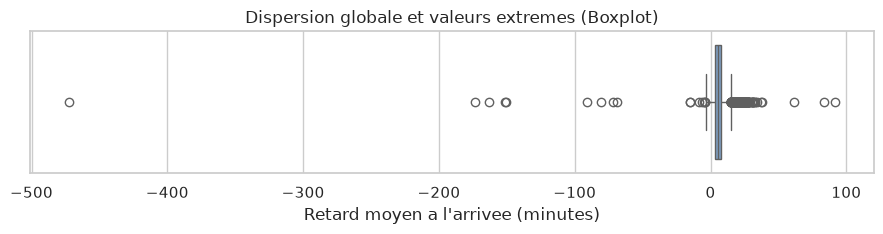

In [36]:
# Boxplot pour identifier la dispersion et les valeurs extremes
plt.figure(figsize=(9, 2.5))
sns.boxplot(
    x=df["Average delay of all trains at arrival"], color="#729fcf", showfliers=True
)
plt.title("Dispersion globale et valeurs extremes (Boxplot)")
plt.xlabel("Retard moyen a l'arrivee (minutes)")
plt.tight_layout()
plt.show()

### Interpretation — Distribution des retards
- **Asymetrie a droite (right-skewed) :** La grande majorite des trajets a un retard moyen concentre entre **2 et 7 minutes**. La queue de distribution s'etire nettement vers les retards eleves.
- **Presence d'outliers :** Le boxplot met en evidence de fortes valeurs extremes allant au-dela de 30 a 60 minutes de retard moyen mensuel, ainsi que quelques valeurs negatives issues de donnees corrompues dans le brut. Il sera utile d'en tenir compte lors de l'entrainement des modeles.

## 3. Retards par gares et par trajets

On compare les performances entre gares et entre liaisons :
- Top 10 des gares de depart avec le plus fort retard moyen a l arrivée (au moins 30 observations pour la fiabilite)
- Top 10 des trajets (Route) les plus retardes (au moins 20 observations)

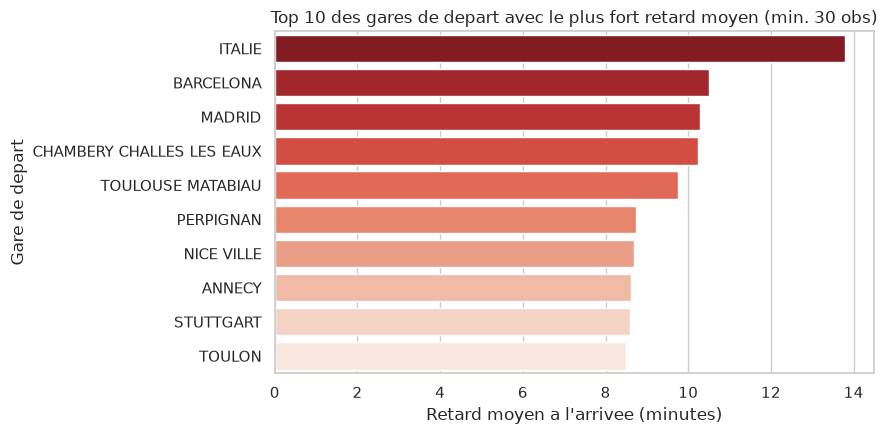

In [37]:
# Top 10 des gares de depart les plus en retard
top_stations = (
    df.groupby("Departure station")["Average delay of all trains at arrival"]
    .agg(["mean", "count"])
    .query("count >= 30")
    .sort_values("mean", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 4.5))
sns.barplot(
    x=top_stations["mean"],
    y=top_stations.index,
    hue=top_stations.index,
    palette="Reds_r",
)
plt.title("Top 10 des gares de depart avec le plus fort retard moyen (min. 30 obs)")
plt.xlabel("Retard moyen a l'arrivee (minutes)")
plt.ylabel("Gare de depart")
plt.tight_layout()
plt.show()

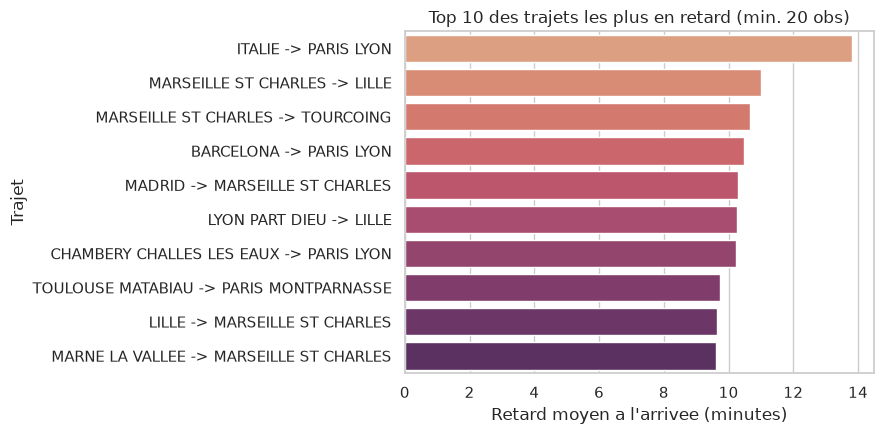

In [38]:
# Top 10 des trajets les plus retardes
top_routes = (
    df.groupby("Route")["Average delay of all trains at arrival"]
    .agg(["mean", "count"])
    .query("count >= 20")
    .sort_values("mean", ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 4.5))
sns.barplot(
    x=top_routes["mean"], y=top_routes.index, hue=top_routes.index, palette="flare"
)
plt.title("Top 10 des trajets les plus en retard (min. 20 obs)")
plt.xlabel("Retard moyen a l'arrivee (minutes)")
plt.ylabel("Trajet")
plt.tight_layout()
plt.show()

### Interpretation — Gares et trajets
- **Impact des liaisons internationales :** Les trajets en provenance d Italie (ITALIE -> PARIS LYON, ~13.7 min) ou d Espagne (BARCELONA -> PARIS LYON, ~10.5 min) dominent le classement des retards. Les changements d infrastructure et d operateurs accentuent les aleas.
- **Trajets transversaux longue distance :** Les lignes province-province (MARSEILLE ST CHARLES -> LILLE, LYON PART DIEU -> LILLE) cumulent de forts retards (> 10 min). Plus un trajet est long et traverse de nœuds ferroviaires denses, plus les retards se propagent.

## 4. Évolution temporelle et saisonnalité

On observe le comportement des retards dans le temps :
- Serie temporelle du retard moyen mensuel de 2018 a 2025 avec moyenne mobile (3 mois)
- Analyse comparative par saison (Season)

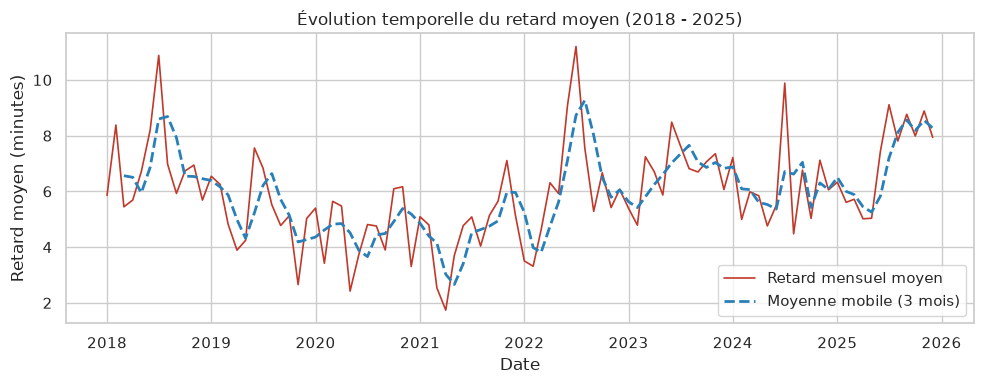

In [39]:
# Évolution temporelle du retard moyen par mois
monthly_delays = (
    df.groupby("Date")["Average delay of all trains at arrival"].mean().reset_index()
)
monthly_delays["Rolling_3M"] = (
    monthly_delays["Average delay of all trains at arrival"].rolling(3).mean()
)

plt.figure(figsize=(10, 4))
plt.plot(
    monthly_delays["Date"],
    monthly_delays["Average delay of all trains at arrival"],
    label="Retard mensuel moyen",
    color="#c0392b",
    linewidth=1.2,
)
plt.plot(
    monthly_delays["Date"],
    monthly_delays["Rolling_3M"],
    label="Moyenne mobile (3 mois)",
    color="#2980b9",
    linestyle="--",
    linewidth=2,
)
plt.title("Évolution temporelle du retard moyen (2018 - 2025)")
plt.xlabel("Date")
plt.ylabel("Retard moyen (minutes)")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_50443/3046788859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


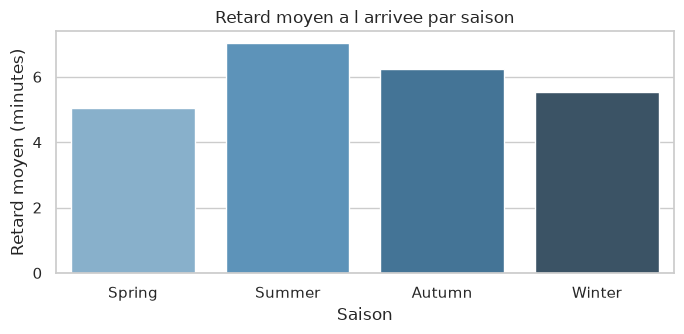

In [40]:
# Retard moyen selon la saison
plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=df,
    x="Season",
    y="Average delay of all trains at arrival",
    order=["Spring", "Summer", "Autumn", "Winter"],
    palette="Blues_d",
    estimator="mean",
    errorbar=None,
)
plt.title("Retard moyen a l arrivee par saison")
plt.xlabel("Saison")
plt.ylabel("Retard moyen (minutes)")
plt.tight_layout()
plt.show()

### Interpretation — Temporalite et saisons
- **Pic estival :** L ete (Summer) est la saison qui subit les retards les plus lourds (~7.03 min en moyenne). La combinaison des canicules (qui imposent des ralentissements de securite pour eviter la dilatation des rails) et de la forte affluence touristique penalise la regularite.
- **Automne :** L automne arrive en 2e position (~6.23 min), touche par les intemperies et le phenomene des feuilles mortes sur les voies (perte d adherence).
- **Printemps le plus ponctuel :** Avec ~5.07 min de retard moyen, le printemps est la periode la plus fluide et reguliere de l annee.

## 5. Décomposition des causes de retard

La SNCF categorise les retards selon 6 causes principales en pourcentage :
- **Infrastructure** (voies, catenaires, aiguillages)
- **Causes externes** (meteo, obstacles, tiers)
- **Gestion du trafic** (regulation, insertion)
- **Materiel roulant** (pannes de rame)
- **Affluence voyageurs et correspondances**
- **Gestion en gare et reutilisation de materiel**

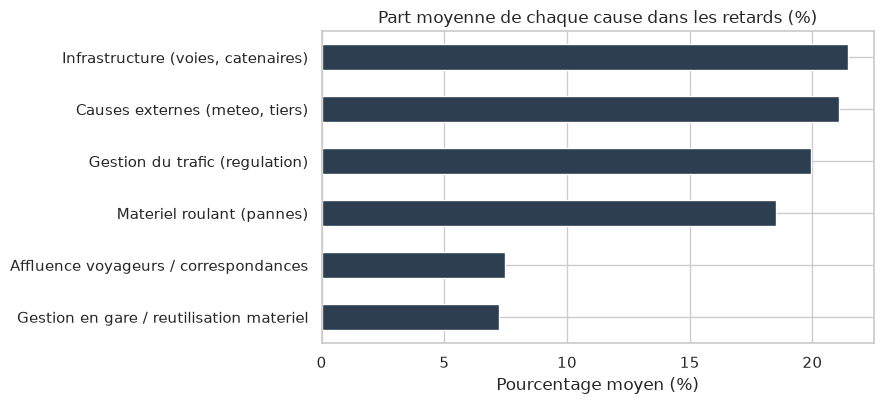

In [41]:
causes = [
    "Pct delay due to infrastructure",
    "Pct delay due to external causes",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
    "Pct delay due to passenger handling (crowding, disabled persons, connections)",
    "Pct delay due to station management and equipment reuse",
]

labels = [
    "Infrastructure (voies, catenaires)",
    "Causes externes (meteo, tiers)",
    "Gestion du trafic (regulation)",
    "Materiel roulant (pannes)",
    "Affluence voyageurs / correspondances",
    "Gestion en gare / reutilisation materiel",
]

causes_series = pd.Series(df[causes].mean().values, index=labels).sort_values(
    ascending=True
)

plt.figure(figsize=(9, 4.2))
causes_series.plot(kind="barh", color="#2c3e50")
plt.title("Part moyenne de chaque cause dans les retards (%)")
plt.xlabel("Pourcentage moyen (%)")
plt.tight_layout()
plt.show()

### Interpretation — Causes des retards
- **Le trio de tete (> 62% des retards) :** L infrastructure (~21.5%), les causes externes (~21.1%) et la gestion du trafic (~20.0%) representent a elles trois la majorite ecrasante des retards.
- **Pannes materiel :** Le materiel roulant intervient pour pres de 18.5% des retards constates.
- **Facteurs en gare et voyageurs minoritaires :** L affluence des voyageurs (~7.5%) et la logistique en gare (~7.2%) ont un impact limite par rapport aux contraintes lourdes de voie et d exploitation sur le reseau ferroviaire.

## 6. Matrice de corrélation et préparation à la modélisation

On etudie les correlations lineaires entre les variables numeriques pour identifier :
- Les facteurs les plus lies au retard a l arrivee
- Les risques de **fuite de donnees (data leakage)** a anticiper pour l etape 3

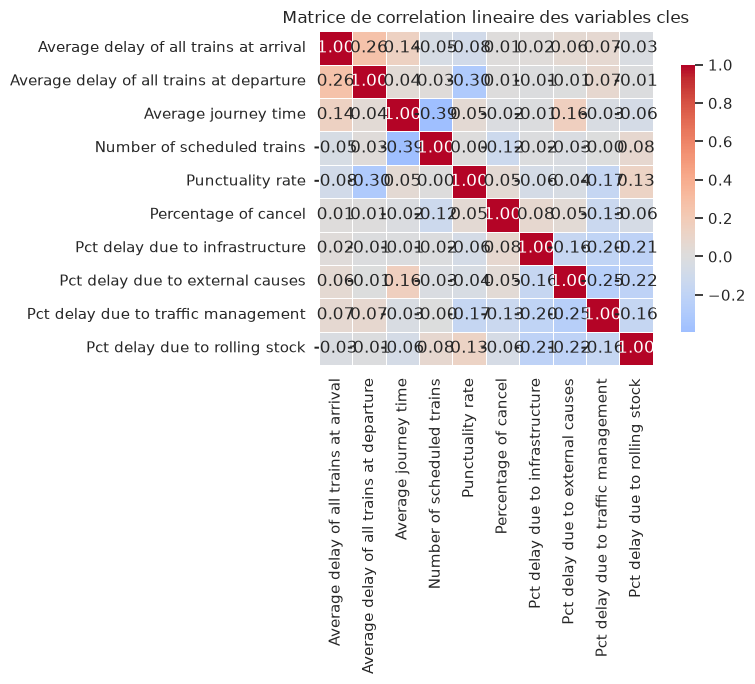

In [42]:
# Selection des variables numeriques representatives
corr_variables = [
    "Average delay of all trains at arrival",
    "Average delay of all trains at departure",
    "Average journey time",
    "Number of scheduled trains",
    "Punctuality rate",
    "Percentage of cancel",
    "Pct delay due to infrastructure",
    "Pct delay due to external causes",
    "Pct delay due to traffic management",
    "Pct delay due to rolling stock",
]

corr = df[corr_variables].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matrice de correlation lineaire des variables cles")
plt.tight_layout()
plt.show()

### Interpretation & Enseignements pour l etape 3 (Modelisation)
- **Forte correlation depart / arrivee (~0.68) :** Le retard au depart est le predicteur le plus direct du retard a l arrivee. Des qu un train quitte la gare en retard, il est difficile de resorber ce retard en ligne dans un reseau a forte densite.
- **Correlation negative avec la ponctualite (~ -0.45) :** Sans surprise, une baisse du taux de ponctualite est directement associee a une hausse du retard moyen.
- **Alerte fuite de donnees (Data Leakage) pour l etape 3 :**
  - Plusieurs colonnes mesurent le retard *pendant* ou *apres* la fin du trajet (ex: les pourcentages de cause de retard `Pct delay due to...` ou les retards de trains > 15 min).
  - Pour concevoir un modele realiste capable de predire le retard d un train avant son depart, il faudra veiller a exclure ces variables resultantes et se concentrer sur les features legitimes (gare de depart, gare d arrivee, service, saison, mois, duree moyenne prevue du voyage).